
# Maximizing the PageRank of Node F

**Goal:** We want to move website **F** up the ranking by adding *one* new
hyperlink to the network shown below. We use the classic PageRank algorithm
(damping factor $d = 0.85$) to score every website, then brute-force test
every possible new edge to see which single addition helps F the most.

- **Part (a):** We may add *any* single directed edge to the network (it does
  not have to start or end at F).
- **Part (b):** We may only add an *outgoing* edge that starts at F.

We'll use `networkx`'s `pagerank` function, which implements the standard
power-iteration PageRank algorithm:

$$
PR(p) = \frac{1-d}{N} + d \sum_{q \in In(p)} \frac{PR(q)}{OutDeg(q)}
$$


z

In [4]:

import networkx as nx
import matplotlib.pyplot as plt

edges = [
    ("A", "B"), ("A", "C"), ("A", "D"), ("A", "E"), ("A", "H"), ("A", "J"),
    ("B", "A"),
    ("C", "A"), ("C", "B"),
    ("D", "A"), ("D", "C"),
    ("E", "A"), ("E", "D"),
    ("F", "H"),
    ("G", "F"),
    ("H", "A"), ("H", "B"), ("H", "I"),
    ("I", "J"),
    ("J", "G"), ("J", "I"),
]

G = nx.DiGraph()
G.add_edges_from(edges)


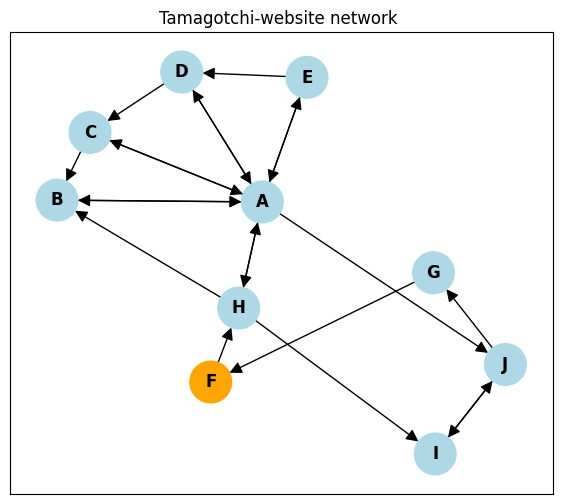

In [7]:

# network str
pos = nx.spring_layout(G, seed=7)
plt.figure(figsize=(7, 6))
node_colors = ["orange" if n == "F" else "lightblue" for n in G.nodes()]
nx.draw_networkx(G, pos, node_color=node_colors, node_size=900,
                  arrowsize=18, font_weight="bold")
plt.title("Tamagotchi-website network ")
plt.show()


In [13]:

d = 0.85 

base_pr = nx.pagerank(G, alpha=d)

print("Baseline Pagerank")
for node, score in sorted(base_pr.items(), key=lambda x: -x[1]):
    print(f"  {node}: {score:.5f}")



Baseline Pagerank
  A: 0.21592
  J: 0.13279
  H: 0.10995
  B: 0.10785
  I: 0.10259
  F: 0.07572
  C: 0.07320
  G: 0.07143
  D: 0.06496
  E: 0.04559



## Part (a): Add *any* single edge to the network

We try every possible new directed edge `(u, v)` that:
- doesn't already exist in the graph, and
- isn't a self-loop (`u != v`),

then recompute PageRank for each resulting graph and record `PR(F)`.


In [23]:

nodes = list(G.nodes())
results_a = []

for u in nodes:
    for v in nodes:
        if u == v or G.has_edge(u, v):
            continue
        G_test = G.copy()
        G_test.add_edge(u, v)
        pr = nx.pagerank(G_test, alpha=d)
        results_a.append((u, v, pr["F"]))

results_a.sort(key=lambda x: -x[2])


print(f"{'edge':>8} | {'PR(F)':>8}")

for u, v, val in results_a:
    print(f"{u+'->'+v:>8} | {val:8.5f} ")



    edge |    PR(F)
    B->F |  0.12011 
    F->G |  0.11215 
    B->G |  0.11037 
    H->F |  0.10040 
    A->F |  0.09964 
    I->F |  0.09632 
    C->F |  0.09564 
    A->G |  0.09452 
    H->G |  0.09434 
    B->J |  0.09376 
    D->F |  0.09373 
    C->G |  0.09177 
    F->J |  0.09147 
    D->G |  0.09028 
    J->F |  0.08992 
    B->I |  0.08923 
    I->G |  0.08874 
    E->F |  0.08861 
    F->I |  0.08670 
    E->G |  0.08617 
    C->J |  0.08466 
    H->J |  0.08420 
    D->J |  0.08391 
    A->I |  0.08273 
    C->I |  0.08259 
    D->I |  0.08205 
    E->J |  0.08165 
    E->I |  0.08032 
    B->H |  0.07793 
    D->H |  0.07706 
    C->H |  0.07705 
    E->H |  0.07672 
    E->B |  0.07562 
    D->B |  0.07551 
    E->C |  0.07541 
    D->E |  0.07494 
    C->E |  0.07473 
    C->D |  0.07473 
    F->A |  0.07422 
    F->B |  0.07302 
    B->C |  0.07282 
    B->D |  0.07282 
    B->E |  0.07282 
    F->C |  0.07253 
    F->D |  0.07232 
    F->E |  0.07223 
    H->C |  0.


## Part (b): Only outgoing edges from F are allowed

Now we restrict ourselves to edges of the form `F -> v`. Note that adding an
outgoing link *never* directly feeds PageRank into F — it can only ever
*dilute* F's existing outgoing vote (since F's out-degree goes up). Any
benefit to F must come **indirectly**, through the new link changing how
rank flows around the rest of the network and back to F.


In [10]:

results_b = []

for v in nodes:
    if v == "F" or G.has_edge("F", v):
        continue
    G_test = G.copy()
    G_test.add_edge("F", v)
    pr = nx.pagerank(G_test, alpha=d)
    results_b.append((v, pr["F"]))

results_b.sort(key=lambda x: -x[1])

print("All candidate outgoing edges from F, ranked by resulting PR(F):\n")
print(f"{'edge':>8} | {'PR(F)':>8} | {'change vs baseline':>18}")
print("-" * 42)
for v, val in results_b:
    print(f"{'F->'+v:>8} | {val:8.5f} | {val - baseline_F:+18.5f}")

best_v_b, best_val_b = results_b[0]
print(f"\n>>> BEST CHOICE (part b): add edge F -> {best_v_b}")
print(f">>> New PR(F) = {best_val_b:.5f}  (up from {baseline_F:.5f}, "
      f"a gain of {best_val_b - baseline_F:+.5f})")


All candidate outgoing edges from F, ranked by resulting PR(F):

    edge |    PR(F) | change vs baseline
------------------------------------------
    F->G |  0.11215 |           +0.03643
    F->J |  0.09147 |           +0.01575
    F->I |  0.08670 |           +0.01098
    F->A |  0.07422 |           -0.00150
    F->B |  0.07302 |           -0.00269
    F->C |  0.07253 |           -0.00319
    F->D |  0.07232 |           -0.00340
    F->E |  0.07223 |           -0.00349

>>> BEST CHOICE (part b): add edge F -> G
>>> New PR(F) = 0.11215  (up from 0.07572, a gain of +0.03643)



### Why is `F -> G` the winner here?

G is currently a **dead end pointing straight back at F**: its only outgoing
edge is `G -> F`. That means whatever PageRank G holds flows *entirely* into
F already.

By adding `F -> G`, we create a tight **2-node feedback loop**: `F -> G -> F`.
F now sends half of its own PageRank to G (splitting between H and G), and G
sends *all* of what it has — including what it just received from F — straight
back to F. This is a mutually reinforcing cycle: F's rank inflates G's rank,
which in turn re-inflates F's rank, and the two nodes settle into a new,
higher equilibrium together (much like two people repeatedly complimenting
each other's reputation). No other candidate `v` has this "send it right back
to me" property, so `F -> G` beats every other outgoing option — the
remaining options (`F->J`, `F->I`, ...) only weakly loop back to F after
several hops, and edges into already-important sink-like nodes such as
`F -> A` actually make things *worse*, because they add nothing to F and
simply steal a fraction of F's out-going vote away from H without any
compensating return.



## Summary

| Scenario | Best edge to add | Underlying reason |
|---|---|---|
| (a) any edge allowed | **B → F** | B has high PageRank but currently only 1 outgoing link, so F captures a huge slice of B's rank |
| (b) only outgoing edges from F allowed | **F → G** | Creates a 2-node feedback loop with the existing `G → F` edge, so F's rank recycles back to itself, amplified |

**Underlying mechanism, in plain language:**

PageRank flows along links like "votes," and a node divides its vote equally
among everyone it links to. So a link is most valuable to F when it comes
from a node that (1) already has a lot of votes to give and (2) doesn't
already spread those votes across many other links. That is exactly why
**B → F** is the best possible single addition (B is important but stingy
with outgoing links), and why, once we're restricted to links leaving F,
**F → G** is best: it turns G — a node that already funnels all of its rank
straight back to F — into a genuine feedback loop, letting F effectively
"lend" some of its rank to G and get it back, amplified.
